<a href="https://colab.research.google.com/github/SnehasishKabi/MOVIE_RECOMMENDATION_SYSTEM/blob/main/bda_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.sql.functions import col

spark = SparkSession.builder.appName("ALS Recommendation System").getOrCreate()

data = spark.read.csv("/content/rating.csv", header=True, inferSchema=True)

data.show()

# Step 3: Preprocess data
# Ensure columns are in the correct format
data = data.select(
    col("userId").cast("integer"),
    col("movieId").cast("integer"),
    col("rating").cast("float"),
    col("timestamp")
)

(training, test) = data.randomSplit([0.8, 0.2])

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    nonnegative=True,
    implicitPrefs=False,
    coldStartStrategy="drop"
)

model = als.fit(training)

predictions = model.transform(test)

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)
rmse = evaluator.evaluate(predictions)
print(f"Root Mean Square Error (RMSE): {rmse}")

user_recommendations = model.recommendForAllUsers(10)
user_recommendations.show()

movie_recommendations = model.recommendForAllItems(10)
movie_recommendations.show()

spark.stop()


+------+-------+------+-------------------+
|userId|movieId|rating|          timestamp|
+------+-------+------+-------------------+
|     1|      2|   3.5|2005-04-02 23:53:47|
|     1|     29|   3.5|2005-04-02 23:31:16|
|     1|     32|   3.5|2005-04-02 23:33:39|
|     1|     47|   3.5|2005-04-02 23:32:07|
|     1|     50|   3.5|2005-04-02 23:29:40|
|     1|    112|   3.5|2004-09-10 03:09:00|
|     1|    151|   4.0|2004-09-10 03:08:54|
|     1|    223|   4.0|2005-04-02 23:46:13|
|     1|    253|   4.0|2005-04-02 23:35:40|
|     1|    260|   4.0|2005-04-02 23:33:46|
|     1|    293|   4.0|2005-04-02 23:31:43|
|     1|    296|   4.0|2005-04-02 23:32:47|
|     1|    318|   4.0|2005-04-02 23:33:18|
|     1|    337|   3.5|2004-09-10 03:08:29|
|     1|    367|   3.5|2005-04-02 23:53:00|
|     1|    541|   4.0|2005-04-02 23:30:03|
|     1|    589|   3.5|2005-04-02 23:45:57|
|     1|    593|   3.5|2005-04-02 23:31:01|
|     1|    653|   3.0|2004-09-10 03:08:11|
|     1|    919|   3.5|2004-09-1

Root Mean Square Error (RMSE): 0.8140952822843182


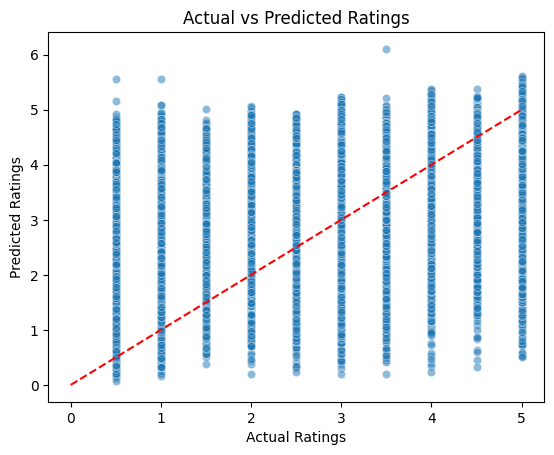

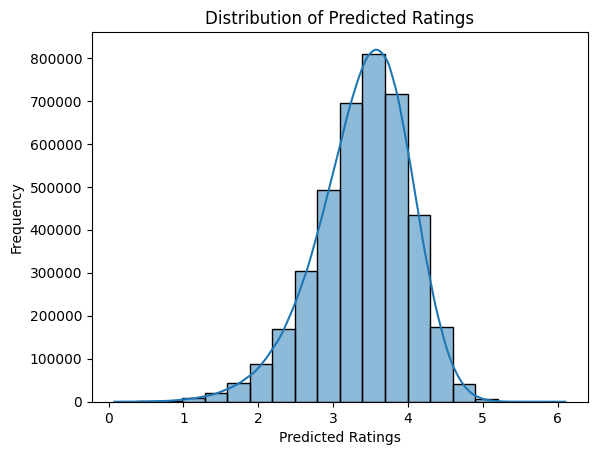

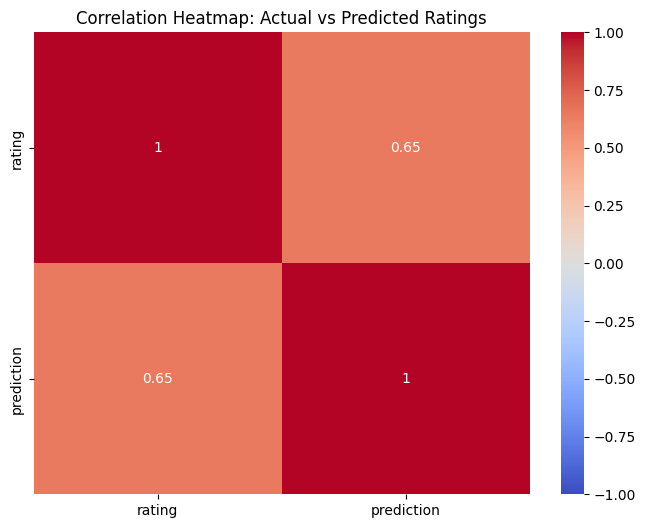

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.sql.functions import col
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def initialize_spark(app_name="ALS Recommendation System"):
    """Initialize a Spark session."""
    return SparkSession.builder.appName(app_name).getOrCreate()


def load_and_preprocess_data(spark, file_path):
    """Load and preprocess the dataset."""
    try:
        data = spark.read.csv(file_path, header=True, inferSchema=True)
        data = data.select(
            col("userId").cast("integer"),
            col("movieId").cast("integer"),
            col("rating").cast("float"),
            col("timestamp")
        )
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None


def train_als_model(training_data):
    """Train the ALS model."""
    als = ALS(
        userCol="userId",
        itemCol="movieId",
        ratingCol="rating",
        nonnegative=True,
        implicitPrefs=False,
        coldStartStrategy="drop"
    )
    return als.fit(training_data)


def evaluate_model(predictions):
    """Evaluate the ALS model using RMSE."""
    evaluator = RegressionEvaluator(
        metricName="rmse",
        labelCol="rating",
        predictionCol="prediction"
    )
    rmse = evaluator.evaluate(predictions)
    print(f"Root Mean Square Error (RMSE): {rmse}")
    return rmse


def generate_and_plot_recommendations(model, predictions):
    """Generate recommendations and create plots."""
    user_recommendations = model.recommendForAllUsers(10).toPandas()
    movie_recommendations = model.recommendForAllItems(10).toPandas()

    # Plot actual vs predicted ratings
    predictions_df = predictions.select("rating", "prediction").toPandas()
    sns.scatterplot(x="rating", y="prediction", data=predictions_df, alpha=0.5)
    plt.plot([0, 5], [0, 5], color="red", linestyle="--")
    plt.xlabel("Actual Ratings")
    plt.ylabel("Predicted Ratings")
    plt.title("Actual vs Predicted Ratings")
    plt.show()

    # Plot distribution of predicted ratings
    sns.histplot(predictions_df["prediction"], bins=20, kde=True)
    plt.xlabel("Predicted Ratings")
    plt.ylabel("Frequency")
    plt.title("Distribution of Predicted Ratings")
    plt.show()

    # Heatmap: Correlation matrix between actual and predicted ratings
    correlation_matrix = predictions_df[['rating', 'prediction']].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Correlation Heatmap: Actual vs Predicted Ratings")
    plt.show()

    return user_recommendations, movie_recommendations


def main():
    spark = initialize_spark()
    file_path = "/content/rating.csv"

    # Step 1: Load and preprocess data
    data = load_and_preprocess_data(spark, file_path)
    if data is None:
        spark.stop()
        return

    # Step 2: Split the dataset
    training, test = data.randomSplit([0.8, 0.2])

    # Step 3: Train the ALS model
    model = train_als_model(training)

    # Step 4: Evaluate the model
    predictions = model.transform(test)
    evaluate_model(predictions)

    # Step 5: Generate recommendations and plot results
    generate_and_plot_recommendations(model, predictions)

    # Stop SparkSession
    spark.stop()


if __name__ == "__main__":
    main()


In [ ]:
# Install PySpark
!pip install pyspark

# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, split, lit
from pyspark.ml.feature import CountVectorizer
from pyspark.ml.linalg import DenseVector

# Step 1: Initialize SparkSession
spark = SparkSession.builder.appName("Content-Based Recommendation").getOrCreate()

# Step 2: Load the datasets
ratings_path = "/content/rating.csv"  # Replace with the correct path
movies_path = "/content/movie.csv"    # Replace with the correct path

ratings = spark.read.csv(ratings_path, header=True, inferSchema=True)
movies = spark.read.csv(movies_path, header=True, inferSchema=True)

# Preview datasets
ratings.show(5)
movies.show(5)

# Step 3: Process the movies dataset
# Split genres into an array of individual terms
movies = movies.withColumn("genres_array", split(col("genres"), "\\|"))

# Step 4: Create genre features using CountVectorizer
from pyspark.ml.feature import CountVectorizer
vectorizer = CountVectorizer(inputCol="genres_array", outputCol="genre_features")
movies_features = vectorizer.fit(movies).transform(movies)

# Preview the movies dataset with genre features
movies_features.show(5)

# Step 5: Aggregate user preferences by genre
# Join ratings with movie features
ratings_movies = ratings.join(movies_features, on="movieId", how="inner")

# Calculate user profiles (weighted average of genre features by ratings)
user_profiles = ratings_movies.groupBy("userId").agg(
    (col("genre_features") * col("rating")).alias("user_genre_vector")
)

# Step 6: Recommend movies to a user
# Define a function to calculate cosine similarity between user profile and movie features
def cosine_similarity(vector1, vector2):
    return float(vector1.dot(vector2) / (vector1.norm(2) * vector2.norm(2)))

# For a specific user
user_id = 1  # Change this to the user ID you want to recommend for
user_profile = user_profiles.filter(col("userId") == user_id).select("user_genre_vector").first()[0]

# Calculate similarity scores for all movies
movies_with_scores = movies_features.rdd.map(lambda row: (
    row.movieId,
    row.title,
    cosine_similarity(DenseVector(user_profile), row.genre_features)
))

# Convert to DataFrame and sort by similarity scores
recommendations = spark.createDataFrame(movies_with_scores, ["movieId", "title", "similarity"])
recommendations = recommendations.orderBy(col("similarity").desc())

# Show top recommendations
recommendations.show(10)

# Step 7: Stop the SparkSession
spark.stop()


+------+-------+------+-------------------+
|userId|movieId|rating|          timestamp|
+------+-------+------+-------------------+
|     1|      2|   3.5|2005-04-02 23:53:47|
|     1|     29|   3.5|2005-04-02 23:31:16|
|     1|     32|   3.5|2005-04-02 23:33:39|
|     1|     47|   3.5|2005-04-02 23:32:07|
|     1|     50|   3.5|2005-04-02 23:29:40|
+------+-------+------+-------------------+
only showing top 5 rows

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows

+-------+--------------------+--------------------+--------------------+--------------

AnalysisException: [DATATYPE_MISMATCH.BINARY_OP_DIFF_TYPES] Cannot resolve "(genre_features * rating)" due to data type mismatch: the left and right operands of the binary operator have incompatible types ("STRUCT<type: TINYINT, size: INT, indices: ARRAY<INT>, values: ARRAY<DOUBLE>>" and "DOUBLE").;
'Aggregate [userId#1250], [userId#1250, (genre_features#1331 * rating#1252) AS user_genre_vector#1380]
+- Project [movieId#1251, userId#1250, rating#1252, timestamp#1253, title#1276, genres#1277, genres_array#1320, genre_features#1331]
   +- Join Inner, (movieId#1251 = movieId#1275)
      :- Relation [userId#1250,movieId#1251,rating#1252,timestamp#1253] csv
      +- Project [movieId#1275, title#1276, genres#1277, genres_array#1320, UDF(genres_array#1320) AS genre_features#1331]
         +- Project [movieId#1275, title#1276, genres#1277, split(genres#1277, \|, -1) AS genres_array#1320]
            +- Relation [movieId#1275,title#1276,genres#1277] csv


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import col, udf
from pyspark.sql.types import ArrayType, StringType, FloatType
import numpy as np
from pyspark.ml.feature import Normalizer

spark = SparkSession.builder \
    .appName("MovieRecommender") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

def load_and_prepare_data():
    movies_df = spark.read.csv("/content/movie.csv", header=True, inferSchema=True)
    ratings_df = spark.read.csv("/content/rating.csv", header=True, inferSchema=True)

    movies_df = movies_df.withColumn("movieId", col("movieId").cast("integer"))

    return movies_df, ratings_df

def preprocess_text_features(movies_df):
    tokenizer = RegexTokenizer(inputCol="title", outputCol="title_tokens",
                             pattern="\\W")

    remover = StopWordsRemover(inputCol="title_tokens", outputCol="filtered_tokens")

    countVectorizer = CountVectorizer(inputCol="filtered_tokens",
                                    outputCol="title_tf",
                                    minDF=2.0)

    idf = IDF(inputCol="title_tf", outputCol="title_tfidf")


    split_genres = udf(lambda x: x.split("|") if x else [],
                      ArrayType(StringType()))
    movies_df = movies_df.withColumn("genres_array",
                                    split_genres(col("genres")))

    genreVectorizer = CountVectorizer(inputCol="genres_array",
                                    outputCol="genre_features",
                                    minDF=1.0)

    pipeline = Pipeline(stages=[
        tokenizer,
        remover,
        countVectorizer,
        idf,
        genreVectorizer
    ])

    model = pipeline.fit(movies_df)
    processed_df = model.transform(movies_df)

    return processed_df, model

def create_feature_vector(processed_df):
    assembler = VectorAssembler(
        inputCols=["title_tfidf", "genre_features"],
        outputCol="features"
    )

    normalizer = Normalizer(inputCol="features", outputCol="normalized_features")

    feature_pipeline = Pipeline(stages=[assembler, normalizer])
    final_df = feature_pipeline.fit(processed_df).transform(processed_df)

    return final_df

def get_recommendations(movie_id, final_df, n=5):
    input_movie = final_df.filter(col("movieId") == movie_id).first()

    if not input_movie:
        raise ValueError(f"Movie ID {movie_id} not found in the dataset")

    input_vector = input_movie.normalized_features

    def cosine_similarity(vec1, vec2):
        return float(vec1.dot(vec2))

    similarity_udf = udf(lambda x: cosine_similarity(input_vector, x),
                        FloatType())

    recommendations = final_df.filter(col("movieId") != movie_id) \
        .withColumn("similarity", similarity_udf(col("normalized_features"))) \
        .orderBy(col("similarity").desc()) \
        .limit(n)

    return recommendations.select("movieId", "title", "genres", "similarity")

def main():
    try:
        print("Loading data...")
        movies_df, ratings_df = load_and_prepare_data()

        print("Preprocessing features...")
        processed_df, pipeline_model = preprocess_text_features(movies_df)

        print("Creating feature vectors...")
        final_df = create_feature_vector(processed_df)

        final_df.cache()


        movie_id = 1
        print(f"\nGetting recommendations for movie ID {movie_id}...")

        input_movie_title = final_df.filter(col("movieId") == movie_id).select("title").first()
        if input_movie_title:
            print(f"Input movie: {input_movie_title.title}")

        recommendations = get_recommendations(movie_id, final_df)

        print("\nTop 5 recommendations:")
        recommendations.show(truncate=False)

    except Exception as e:
        print(f"An error occurred: {str(e)}")
    finally:
        spark.stop()

if __name__ == "__main__":
    main()

Loading data...
Preprocessing features...
Creating feature vectors...

Getting recommendations for movie ID 1...
Input movie: Toy Story (1995)

Top 5 recommendations:
+-------+--------------------------+------------------------------------------------+----------+
|movieId|title                     |genres                                          |similarity|
+-------+--------------------------+------------------------------------------------+----------+
|3114   |Toy Story 2 (1999)        |Adventure|Animation|Children|Comedy|Fantasy     |0.76821506|
|78499  |Toy Story 3 (2010)        |Adventure|Animation|Children|Comedy|Fantasy|IMAX|0.7532216 |
|106022 |Toy Story of Terror (2013)|Animation|Children|Comedy                       |0.7050196 |
|4929   |Toy, The (1982)           |Comedy                                          |0.6424517 |
|2274   |Lilian's Story (1995)     |Drama                                           |0.6130839 |
+-------+--------------------------+---------------------

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Normalizer
from pyspark.ml.recommendation import ALS
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, udf, expr, broadcast, explode
from pyspark.sql.types import ArrayType, StringType, FloatType, IntegerType
import numpy as np

spark = SparkSession.builder \
    .appName("HybridMovieRecommender") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "100") \
    .getOrCreate()

def load_data():
    movies_df = spark.read.csv("/content/movie.csv", header=True, inferSchema=True)
    ratings_df = spark.read.csv("/content/rating.csv", header=True, inferSchema=True)

    movies_df = movies_df.withColumn("movieId", col("movieId").cast(IntegerType()))
    ratings_df = ratings_df.withColumn("movieId", col("movieId").cast(IntegerType())) \
                          .withColumn("userId", col("userId").cast(IntegerType())) \
                          .withColumn("rating", col("rating").cast(FloatType()))

    return movies_df, ratings_df

def create_content_features(movies_df):
    tokenizer = RegexTokenizer(inputCol="title", outputCol="title_tokens", pattern="\\W")
    remover = StopWordsRemover(inputCol="title_tokens", outputCol="filtered_tokens")
    count_vectorizer = CountVectorizer(inputCol="filtered_tokens", outputCol="title_tf", minDF=2.0)
    idf = IDF(inputCol="title_tf", outputCol="title_tfidf")

    split_genres = udf(lambda x: x.split("|") if x else [], ArrayType(StringType()))
    movies_df = movies_df.withColumn("genres_array", split_genres(col("genres")))
    genre_vectorizer = CountVectorizer(inputCol="genres_array", outputCol="genre_features", minDF=1.0)

    pipeline = Pipeline(stages=[
        tokenizer, remover, count_vectorizer, idf, genre_vectorizer
    ])

    content_model = pipeline.fit(movies_df)
    content_features_df = content_model.transform(movies_df)

    assembler = VectorAssembler(
        inputCols=["title_tfidf", "genre_features"],
        outputCol="combined_features"
    )
    normalizer = Normalizer(inputCol="combined_features", outputCol="normalized_features")

    feature_pipeline = Pipeline(stages=[assembler, normalizer])
    final_features_df = feature_pipeline.fit(content_features_df).transform(content_features_df)

    return final_features_df

def train_collaborative_model(ratings_df):
    # Train ALS model
    als = ALS(maxIter=5,
              regParam=0.01,
              userCol="userId",
              itemCol="movieId",
              ratingCol="rating",
              coldStartStrategy="drop",
              nonnegative=True)

    model = als.fit(ratings_df)
    return model

def get_content_similarity(movie_id, content_features_df, n=100):
    # Get content-based similarities
    input_movie = content_features_df.filter(col("movieId") == movie_id).first()
    input_vector = input_movie.normalized_features

    def cosine_similarity(vec1, vec2):
        return float(vec1.dot(vec2))

    similarity_udf = udf(lambda x: cosine_similarity(input_vector, x), FloatType())

    content_recommendations = content_features_df.filter(col("movieId") != movie_id) \
        .withColumn("content_score", similarity_udf(col("normalized_features"))) \
        .select("movieId", "content_score")

    return content_recommendations

def get_hybrid_recommendations(user_id, movie_id, content_features_df,
                             collaborative_model, n=10, content_weight=0.3):

    content_scores = get_content_similarity(movie_id, content_features_df)


    users_df = spark.createDataFrame([(user_id,)], ["userId"])

    cf_recommendations = collaborative_model.recommendForUserSubset(users_df, 100)

    cf_scores = cf_recommendations.select(
        explode("recommendations").alias("rec")
    ).select(
        col("rec.movieId").alias("movieId"),
        col("rec.rating").alias("cf_score")
    )

    hybrid_scores = cf_scores.join(broadcast(content_scores), "movieId", "inner")

    hybrid_recommendations = hybrid_scores \
        .withColumn("hybrid_score",
                   (1 - content_weight) * col("cf_score") + content_weight * col("content_score")) \
        .join(content_features_df.select("movieId", "title", "genres"), "movieId") \
        .orderBy(col("hybrid_score").desc()) \
        .select("movieId", "title", "genres", "hybrid_score", "cf_score", "content_score") \
        .limit(n)

    return hybrid_recommendations

def main():
    try:
        print("Loading data...")
        movies_df, ratings_df = load_data()

        print("Creating content features...")
        content_features_df = create_content_features(movies_df)

        print("Training collaborative filtering model...")
        collaborative_model = train_collaborative_model(ratings_df)

        user_id = 1
        movie_id = 1

        print(f"\nGetting hybrid recommendations for user {user_id} based on movie {movie_id}...")
        recommendations = get_hybrid_recommendations(
            user_id, movie_id, content_features_df, collaborative_model
        )

        print("\nTop 10 Hybrid Recommendations:")
        recommendations.show(truncate=False)

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        print(traceback.format_exc())
    finally:
        spark.stop()

if __name__ == "__main__":
    main()

Loading data...
Creating content features...
Training collaborative filtering model...

Getting hybrid recommendations for user 1 based on movie 1...

Top 10 Hybrid Recommendations:
+-------+-----------------------------------------------------------+----------------------------+------------------+---------+-------------+
|movieId|title                                                      |genres                      |hybrid_score      |cf_score |content_score|
+-------+-----------------------------------------------------------+----------------------------+------------------+---------+-------------+
|130852 |Brothers on the Line (2012)                                |(no genres listed)          |15.112205696105956|21.588865|0.0          |
|113048 |Tables Turned on the Gardener (1895)                       |Comedy                      |9.938583002937957 |14.195575|0.0056022354 |
|89632  |Masti (2004)                                               |Comedy                      |8.53640976